This tutorial follows the work from Tikai Chang et al. 'Strong coupling of a superconducting flux qubit to single bismuth donors', Nature Communications 10.1038/s41467-025-64757-5. In this work, a spin qubit from a bismuth donor is coupled to a superconducting flux qubit. QuaCCAToo models both qubit systems within the `SiBi_flux` class.

In [1]:
import numpy as np
import scipy.constants as cte
from qutip import basis, fock_dm, jmat, qeye, tensor

gamma_e = cte.value("electron gyromag. ratio in MHz/T") * 1e-3

from quaccatoo import Analysis, Ramsey, SiBiFlux, SpinLocking

# Flux Qubit

We begin reproducing the results from the flux qubit characterization as shown in the Results section and in Fig 1. We assume the same experimental values for $\Delta$, $\Gamma^{2R}$ and $\Omega$ as in the text. For $\varepsilon$, we take an arbitrary value to match the experimental results. An object of the `SiBi_flux` class is instantiated considering an initial state $|0\rangle$, observable $|0\rangle \langle 0|$ and collapse operator $\sqrt{\Gamma^{2R}} \hat{S}_z$. The `spin` variable in this experiment is set to `False`, since the spin Hamiltonian does not need to be simulated.

In [4]:
Delta = 7.257e3
epsilon = 400
Omega = 60.5
L2 = 0.627**.5*jmat(1/2, 'z')

sys = SiBiFlux(
    rho0 = basis(2,0),
    observable = fock_dm(2,0),
    Delta = Delta,
    epsilon = epsilon,
    c_ops = L2,
    spin = False,
)

Based on the defined system, we instantiate a Ramsey sequence from the corresponding predefined class in QuaCCAToo and run the simulation, from which we obtain a decaying Ramsey fringe as in Fig 1h of the text.

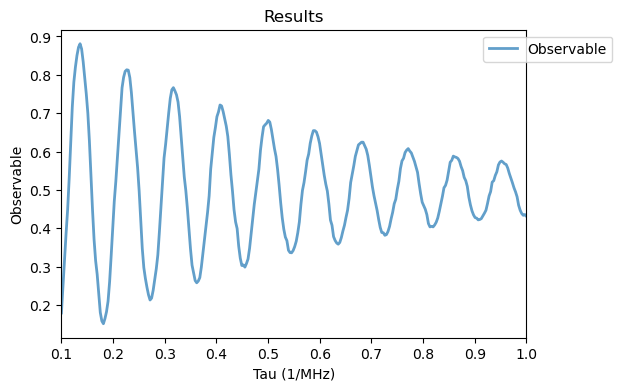

In [5]:
ramsey_sim = Ramsey(
    free_duration=np.linspace(.1, 1, 300),
    system = sys,
    pi_pulse_duration = 1/2/Omega,
    h1 = 2*Omega*jmat(1/2, 'x'),
    pulse_params = {'f_pulse': Delta}
)

ramsey_sim.run()
Analysis(ramsey_sim).plot_results()

# Spin-Locking

Following the Ramsey simulation of the flux qubit, we now couple both qubits in a spin-locking experiment as in Fig 2d. The bismuth electron spin must be brought into resonance with the driven flux qubit $\omega_s = \Delta + \Omega = 7.3175$ GHz, which is the flip-flop condition used in the text. Here we set `N = False`, so the nuclear spin and the hyperfine term of Eq. (3) are not simulated. In the actual experiment the ∼7.3 GHz spin transition originates almost entirely from the hyperfine interaction, not from a Zeeman splitting. Without the hyperfine term, we can place the electron spin at the required frequency through the electron Zeeman energy by imposing $B_0 = (\Delta + \Omega)/\gamma_e \approx 261$ mT, even though this is not the experimental condition. 

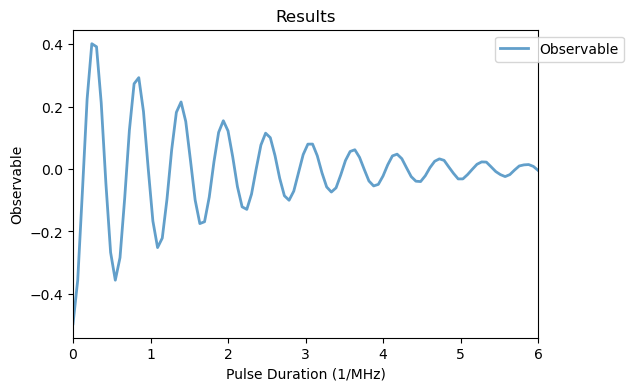

In [6]:
Delta = 7.257e3
Omega = 60.5
g = 4*1.8
B0 = (Delta + Omega)/gamma_e
L1 = 0.150**.5*tensor(jmat(1/2, '-'), qeye(2))

init_state = tensor(basis(2,0), basis(2,0))
obs = tensor(jmat(1/2, 'z'), qeye(2))

sys = SiBiFlux(
    rho0 = init_state,
    observable = obs,
    Delta = Delta,
    B0 = B0,
    g = g,
    N = False,
    c_ops = L1
)

spin_lock_sim = SpinLocking(
    pulse_duration=np.linspace(0, 6, 100),
    system = sys,
    pi_pulse_duration = 1/2/Omega,
    h1 = 2*Omega*tensor(jmat(1/2, 'x'), qeye(2)),
    pulse_params = {'f_pulse': Delta},
    options = {'nsteps':1e6}
)

spin_lock_sim.run()
Analysis(spin_lock_sim).plot_results()